# 激活函数

我们一直着眼于网络模型的**线性回归**部分，而暂时忽略了 M-P 神经元模型中**激活函数**的部分。

理论上，如果只是线性回归的话，无论多少层的网络模型仍然还是线性变换，并不会和单层网络模型有本质的差别。这也正是我们在上一个章节观察到的现象。

``💡 通用近似定理：数学证明，一个包含至少一个隐藏层和非线性激活函数的网络模型，可以以任意精度逼近任何连续函数。``

要让神经网络真正强大，必须引入**非线性**（Nonlinear）。这就是**激活函数**（Activation Function）可以起到的作用。在线性层之间使用激活函数，可以使网络模型不再局限在线性模型，从而能够学习到输入与输出之间更复杂的关系。

激活函数是人工神经元的一部分。但是在深度学习的实践中，通常都是被设计成单独的一层，和线性层配合使用。

In [21]:
from abc import ABC, abstractmethod

import numpy as np

In [22]:
np.random.seed(42)

## 张量

In [23]:
class Tensor:

    def __init__(self, data):
        self.data = np.array(data)
        self.grad = np.zeros_like(self.data)
        self.gradient_fn = None
        self.parents = set()

    def backward(self):
        if self.gradient_fn is not None:
            self.gradient_fn()

        for p in self.parents:
            p.backward()

    def __str__(self):
        return f'Tensor({self.data})'

## 数据集

In [24]:
class Dataset:

    def __init__(self, batch_size=1):
        self.batch_size = batch_size
        self.load()
        self.train()

    def load(self):
        self.train_data = ([[22.5, 72.0],
                            [31.4, 45.0],
                            [19.8, 85.0],
                            [27.6, 63.0]],
                           [[95],
                            [210],
                            [70],
                            [155]])
        self.test_data = ([[28.1, 58.0]],
                          [[165]])

    def train(self):
        self.data = self.train_data

    def eval(self):
        self.data = self.test_data

    def all(self):
        x, y = self.data
        return Tensor(x), Tensor(y)

    def __len__(self):
        x, *_ = self.data
        return len(x) // self.batch_size

    def __getitem__(self, index):
        s = slice(index * self.batch_size, (index + 1) * self.batch_size)
        x, y = self.data
        return Tensor(x[s]), Tensor(y[s])

## 模型

### 基础层

In [25]:
class Layer(ABC):

    def __call__(self, x: Tensor):
        return self.forward(x)

    @abstractmethod
    def forward(self, x: Tensor):
        pass

    @property
    def parameters(self):
        return []

### 线性层

In [26]:
class Linear(Layer):

    def __init__(self, in_size, out_size):
        self.weight = Tensor(np.random.randn(out_size, in_size) * np.sqrt(2 / in_size))
        self.bias = Tensor(np.zeros(out_size))

    def forward(self, x: Tensor):
        p = Tensor(x.data @ self.weight.data.T + self.bias.data)

        def gradient_fn():
            self.weight.grad += p.grad.T @ x.data
            self.bias.grad += np.sum(p.grad, axis=0)
            x.grad += p.grad @ self.weight.data

        p.gradient_fn = gradient_fn
        p.parents = {x}
        return p

    @property
    def parameters(self):
        return [self.weight, self.bias]

### 顺序层

In [27]:
class Sequential(Layer):

    def __init__(self, layers):
        self.layers = layers

    def forward(self, x: Tensor):
        for l in self.layers:
            x = l(x)
        return x

    @property
    def parameters(self):
        return [p for l in self.layers for p in l.parameters]

## 激活函数

### 线性整流函数（ReLU）

**线性整流函数**（Rectified Linear Unit）ReLU 是目前最常用的**中间隐藏层**激活函数。它的逻辑非常简单：负数归零。

ReLU 激活函数优点非常明显：

* 计算高效，仅需阈值操作；
* 过滤掉所有负数。可以理解为过滤掉所有不重要的信息，或者噪音；
* 所有正数保持不变，在正数区间的导数恒为 1 。因此不会减弱有效信息，导致梯度消失。这对于训练深层网络至关重要。

---

**前向传播**：负数清零。
$$
y = \text{ReLU}(x) = \max(0, x)
$$

**梯度计算**：正数保留梯度。ReLU 激活函数的导数为：
$$
\frac{dy}{dx} = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}
$$

**父节点列表**（parents）：输入值。

**参数列表**（parameters）：无。

In [28]:
class ReLU(Layer):

    def forward(self, x: Tensor):
        a = Tensor(np.maximum(0, x.data))

        def gradient_fn():
            x.grad += a.grad * (a.data > 0)

        a.gradient_fn = gradient_fn
        a.parents = {x}
        return a

我们看一下 ReLU 激活函数的效果：

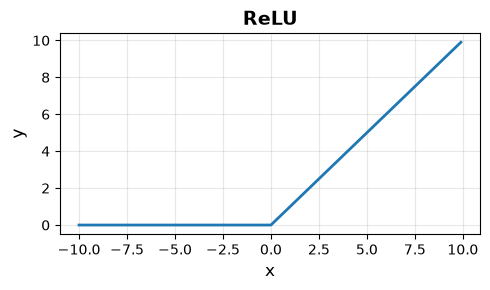

In [30]:
import matplotlib.pyplot as plt

relu = ReLU()

plt.figure(figsize=(5, 3))
x_range = np.arange(-10, 10, 0.1)
plt.plot(x_range, [relu(x).data for x in x_range], linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('ReLU', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 双曲正切函数（Tanh）

**双曲正切函数**（Hyperbolic Tangent）Tanh 可以将任何数值映射到 (-1, 1) 的范围内，同时保持数值之间的相对关系。可以用来消除“曝光过度”造成的极端数值，使数据分布在零点附近。和 ReLU 激活函数一样，常用于**中间隐藏层**。

---

**前向传播**：双曲正切，将输入值映射到 (-1, 1) 范围内。输出值零中心化（均值为 0）。我们直接调用 NumPy 提供的 tanh 函数来计算。
$$
y = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

**梯度计算**：Tanh 激活函数的导数可以用其自身来表达。这意味着我们不需要重新计算复杂的指数函数。Tanh 激活函数的导数为：
$$
\frac{dy}{dx} = 1 - \tanh^2(x) = 1 - y^2
$$

当输入值很大、或者很小的时候，导数会趋近于0。这就是我们常说的**梯度饱和**（Gradient Saturation）现象。在深层网络中，这会导致传回来的信号越来越弱，最终引发梯度消失。

**父节点列表**（parents）：输入值。

**参数列表**（parameters）：无。

In [31]:
class Tanh(Layer):

    def forward(self, x: Tensor):
        a = Tensor(np.tanh(x.data))

        def gradient_fn():
            x.grad += a.grad * (1 - a.data ** 2)

        a.gradient_fn = gradient_fn
        a.parents = {x}
        return a

我们看一下 Tanh 激活函数的效果：

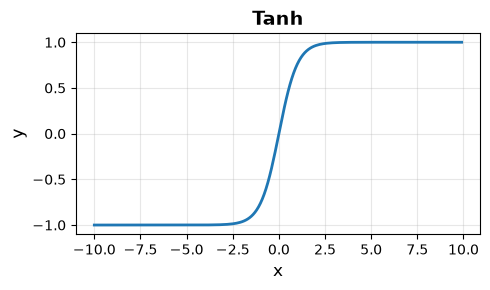

In [35]:
tanh = Tanh()

plt.figure(figsize=(5, 3))
x_range = np.arange(-10, 10, 0.1)
plt.plot(x_range, [tanh(x).data for x in x_range], linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Tanh', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### S形曲线函数（Sigmoid）

**S形曲线函数**（Logistic Curve）Sigmoid 可以把任何数值平滑地压缩到 (0, 1) 的范围之间。因此可以解释为某个事件发生的概率，常用于**二元分类问题的输出层**，来规范预测结果。

---

**前向传播**：逻辑回归的概率，将任意实数映射到 (0, 1) 区间内。常用于二元分类问题的输出层。
$$
y = \sigma(x) = \frac{1}{1 + e^{-x}}
$$

**梯度计算**：Sigmoid 激活函数的导数也可以用其自身来表达。Sigmoid 激活函数的导数为：
$$
\frac{dy}{dx} = \sigma(x) \cdot (1 - \sigma(x)) = y(1 - y)
$$

Sigmoid 激活函数同样存在梯度饱和的问题。在深层网络中，可能梯度消失。而且，Sigmoid 激活函数还存在梯度衰减的问题。

**父节点列表**（parents）：输入值。

**参数列表**（parameters）：无。

In [33]:
class Sigmoid(Layer):

    def __init__(self, clip_range=(-100, 100)):
        super().__init__()
        self.clip_range = clip_range

    def forward(self, x: Tensor):
        z = np.clip(x.data, self.clip_range[0], self.clip_range[1])
        a = Tensor(1 / (1 + np.exp(-z)))

        def gradient_fn():
            x.grad += a.grad * a.data * (1 - a.data)

        a.gradient_fn = gradient_fn
        a.parents = {x}
        return a

我们看一下 Sigmoid 激活函数的效果：

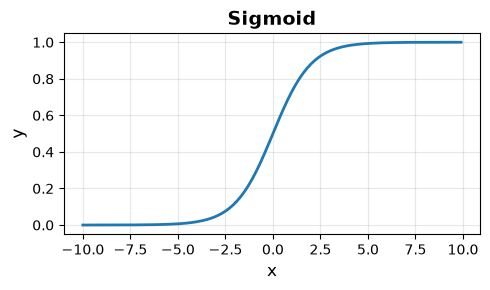

In [36]:
sigmoid = Sigmoid()

plt.figure(figsize=(5, 3))
x_range = np.arange(-10, 10, 0.1)
plt.plot(x_range, [sigmoid(x).data for x in x_range], linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Sigmoid', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 归一化指数函数（Softmax）

**归一化指数函数**（Normalized Exponential）Softmax 用于一组数值的情况，将它们转换为相互之间的相对比例，并维持总和为 1。因此常用于**多元分类问题的输出层**，数值最大的那个选项就是预测结果。

---

**前向传播**：将任意实数向量映射为一个概率分布，使得每个分量位于 (0, 1) 区间内，且所有分量之和为 1。常用于多分元分类问题的输出层。
$$
y_i = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

**梯度计算**：Softmax 激活函数是一个向量函数，其梯度为 Jacobian 矩阵。Softmax 激活函数的导数为：
$$
\frac{dy_i}{dx_i} = g_i - \sum_{j=1}^{n} y_i g_i
$$

**父节点列表**（parents）：输入值。

**参数列表**（parameters）：无。

In [37]:
class Softmax(Layer):

    def __init__(self, axis=-1):
        super().__init__()
        self.axis = axis

    def forward(self, x: Tensor):
        exp = np.exp(x.data - np.max(x.data, axis=self.axis, keepdims=True))
        a = Tensor(exp / np.sum(exp, axis=self.axis, keepdims=True))

        def gradient_fn():
            grad = np.sum(a.data * a.grad, axis=self.axis, keepdims=True)
            x.grad += a.data * (a.grad - grad)

        a.gradient_fn = gradient_fn
        a.parents = {x}
        return a

我们看一下 Softmax 激活函数的效果：

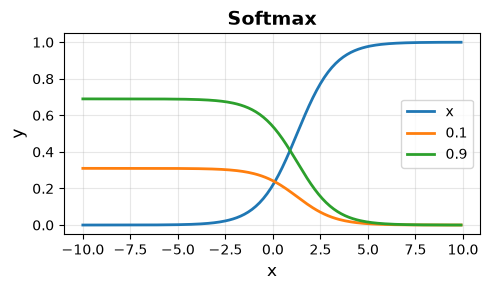

In [38]:
softmax = Softmax()

x_range = np.arange(-10, 10, 0.1)
plt.figure(figsize=(5, 3))
plt.plot(x_range, [softmax(Tensor([x,0.1,0.9])).data for x in x_range], linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Softmax', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend(['x', '0.1', '0.9'])
plt.show()

Softmax 激活函数是一个向量函数。所以我们可以看到各分量之间相互关系的变化。

## 损失函数（均方误差）

In [12]:
class MSELoss:

    def __call__(self, p: Tensor, y: Tensor):
        return self.loss(p, y)

    def loss(self, p: Tensor, y: Tensor):
        mse = Tensor(np.mean(np.square(y.data - p.data)))

        def gradient_fn():
            p.grad += -2 * (y.data - p.data) / y.data.size

        mse.gradient_fn = gradient_fn
        mse.parents = {p}
        return mse

## 优化器（随机梯度下降）

In [13]:
class SGDOptimizer:

    def __init__(self, parameters, lr):
        self.parameters = parameters
        self.lr = lr

    def zero_grad(self):
        for p in self.parameters:
            p.grad = np.zeros_like(p.data)

    def step(self):
        for p in self.parameters:
            p.data -= p.grad * self.lr

## 训练器

In [14]:
class Trainer:

    def __init__(self, layer, loss_fn, optimizer):
        self.layer = layer
        self.loss_fn = loss_fn
        self.optimizer = optimizer

    def train(self, dataset, epochs):
        dataset.train()

        for epoch in range(epochs):
            for i in range(len(dataset)):
                feature, label = dataset[i]

                self.optimizer.zero_grad()
                prediction = self.layer(feature)
                loss = self.loss_fn(prediction, label)
                loss.backward()
                self.optimizer.step()

    def test(self, dataset):
        dataset.eval()

        feature, label = dataset.all()
        prediction = self.layer(feature)
        loss = self.loss_fn(prediction, label)
        return prediction, loss

## 超参数

### 学习率

In [15]:
LEARNING_RATE = 0.00001

### 批大小

In [16]:
BATCH_SIZE = 2

### 轮数

In [17]:
EPOCHS = 1000

## 建模

现在，让我们把 ReLU 激活函数用到隐藏层之后，看看会有什么样的效果。

``💡 通常在数值回归类型的模型中，输出层后面不需要激活函数。后续我们会看到，在分类模型中，输出层后面也会使用激活函数来辅助决策。``

In [18]:
dataset = Dataset(BATCH_SIZE)
model = Sequential([
    Linear(2, 4),
    ReLU(),
    Linear(4, 1)
])
loss_fn = MSELoss()
optimizer = SGDOptimizer(model.parameters, lr=LEARNING_RATE)
trainer = Trainer(model, loss_fn, optimizer)

## 训练

In [19]:
trainer.train(dataset, EPOCHS)

## 评估

In [20]:
prediction, loss = trainer.test(dataset)
print(f'prediction:\t{prediction}\nloss:\t{loss}')

prediction:	Tensor([[164.60610313]])
loss:	Tensor(0.15515474192848927)


神奇的效果！

在上一个章节里，我们观察到两层网络模型虽然可行，但是并没有表现得比单层网络模型更出色，甚至有所减弱。

但是在我们使用了隐藏层激活函数后，效果大增到损失值接近于 0 的程度。

这表明引入非线性激活函数后，模型具备了更强的表达能力，能够很好地拟合训练数据，并在测试样本上给出合理预测。

## 总结

| 激活函数    |             主要用途 |                                              优点 |                               缺点 |                       推荐位置 |
|:--------|-----------------:|------------------------------------------------:|---------------------------------:|---------------------------:|
| ReLU    | 默认首选<br/>处理非线性特征 |                    计算快<br/>在正区间无梯度饱和<br/>缓解梯度消失 |       负区间梯度为 0<br/>可能导致神经元“永久死亡” |                        隐藏层 |
| Tanh    |          有正负值的数据 |                      输出零中心化（均值为 0）<br/>使下一层收敛更快 |            存在梯度饱和<br/>计算涉及指数，开销大 |                        隐藏层 |
| Sigmoid |         二元分类概率预测 |                 将输出平滑压缩至 (0, 1) 区间<br/>输出可解释为概率 |      输出均值不为 0<br/>严重的梯度饱和<br/>会导致梯度消失 |               二元分类<br/>输出层 |
| Softmax |         多元分类概率预测 |                          处理多个类别的概率<br/>确保概率总和为1 |                计算复杂<br/>受极端数值影响大 |               多元分类<br/>输出层 |

## 课后练习

尝试改用 Tanh 激活函数，或者在输出层后使用 Sigmoid 或者 Softmax 激活函数，看看训练效果如何？